### 1.Importing Required Libraries

In [1]:
# Importing essential libraries such as pandas, numpy, and visualization libraries for data analysis.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 2.📊Loading the Dataset

In [3]:
# The dataset is loaded using pandas into a DataFrame for further processing.

In [4]:
df=pd.read_csv(r"C:\Users\kusuma\Downloads\archive (2)\Walmart.csv")

### 3.🔍 Initial Data Exploration

#### Viewing First Few Rows (df.head())

In [5]:
#This step helps us understand:
#Structure of the dataset
#Column names
#Sample values
# It gives a quick overview of how the data looks.

In [6]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


#### Dataset Shape (df.shape)

In [7]:
#Used to identify:
#Number of rows
#Number of columns
#Helps understand dataset size.

In [8]:
df.shape

(6435, 8)

#### Column Information (df.info())

In [9]:
#Provides:
#Data types of each column
#Non-null values
#Memory usage
#Important for identifying:
#Categorical vs numerical data
#Missing values

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


#### Statistical Summary (df.describe())

In [11]:
#Shows:
#Mean, min, max
#Standard deviation
#Percentiles
# Helps understand distribution of numerical features.

In [12]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


### 3.🧹 Data Cleaning

#### Checking Missing Values

In [13]:
#Identifies columns with missing data.

In [14]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

#### Handling Missing Values

In [15]:
#Missing values are handled using appropriate techniques such as:
#Forward fill
#Mean/median imputation

In [16]:
df = df.ffill()

#### Removing Duplicates

In [17]:
# Ensures data consistency.

In [18]:
df.drop_duplicates(inplace=True)

### 4.🗓️ Feature Engineering

#### Converting Date Column

In [19]:
#The Date column is converted into datetime format for time-based analysis.

In [20]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [21]:
#Verify it worked
df['Date'].head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [22]:
df = df.sort_values('Date')

In [23]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

In [24]:
###Now Verifying  Features

In [25]:
df[['Date','Year','Month','Week']].head()

,Date,Year,Month,Week
0,2010-02-05,2010,2,5
1287,2010-02-05,2010,2,5
5148,2010-02-05,2010,2,5
2288,2010-02-05,2010,2,5
4147,2010-02-05,2010,2,5


###  1: Overall Trend Analysis

<Axes: xlabel='Date'>

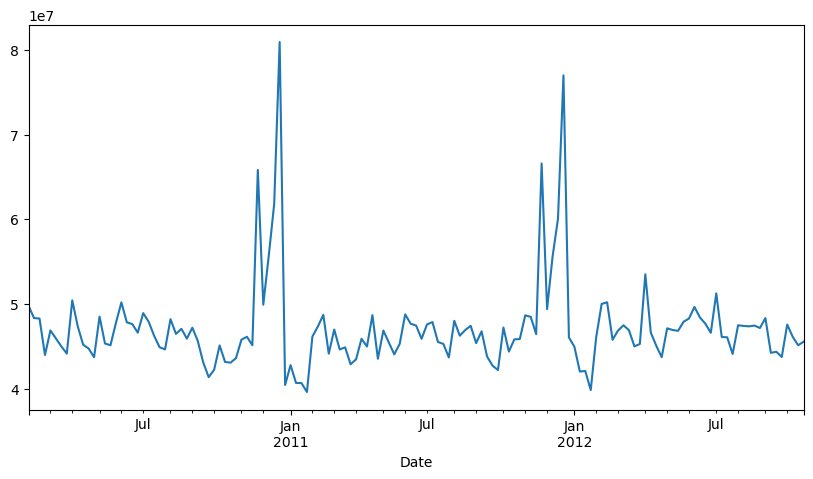

In [26]:
df.groupby('Date')['Weekly_Sales'].sum().plot(figsize=(10,5))

In [27]:
#Observation:
#Sales remain relatively stable for most of the period, fluctuating between moderate values.
#There are sharp spikes in sales at specific points in time.
#These spikes appear periodically (around year-end periods).
#After each spike, there is a sudden drop in sales, followed by stabilization.

In [28]:
#Interpretation:
#The sudden spikes indicate high seasonal demand, most likely during holiday periods (e.g., year-end or festive seasons).
#The immediate drop after spikes suggests that this demand is temporary and event-driven, not sustained.
#The stable pattern during other periods indicates consistent baseline sales throughout the year.

In [29]:
#Business Insight:
#Walmart experiences significant sales boosts during holidays, which are critical revenue periods.
#Outside of these peak times, sales remain steady, showing predictable demand patterns.
#This suggests the importance of:
#Inventory planning before holidays
#Marketing strategies targeting peak seasons

### 2: Monthly Trend

<Axes: xlabel='Month'>

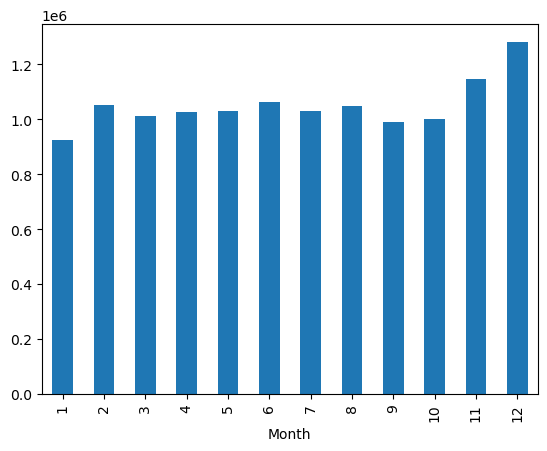

In [30]:
df.groupby('Month')['Weekly_Sales'].mean().plot(kind='bar')

In [31]:
#Interpretation of Monthly Sales Trend
#🔹 Observation:
#Sales are relatively stable across most months, with only slight variations.
#A noticeable increase in sales is observed in the later months, especially November (11) and December (12).
#The lowest sales appear in the early months (around January–March).

In [32]:
#🔹 Interpretation:
#The rise in sales during November and December indicates strong seasonal demand, likely due to holiday and festive shopping periods.
#The lower sales in the beginning of the year suggest reduced consumer spending after the holiday season.
#Overall, the pattern shows a clear seasonal trend, where sales gradually increase towards the end of the year.
#🔹 Business Insight:
#End-of-year months are critical revenue periods and should be prioritized for:
#Inventory stocking
#Marketing campaigns
#Early months may require:
#Promotions or discounts to boost sales

###  3: Weekly Trend

<Axes: xlabel='Week'>

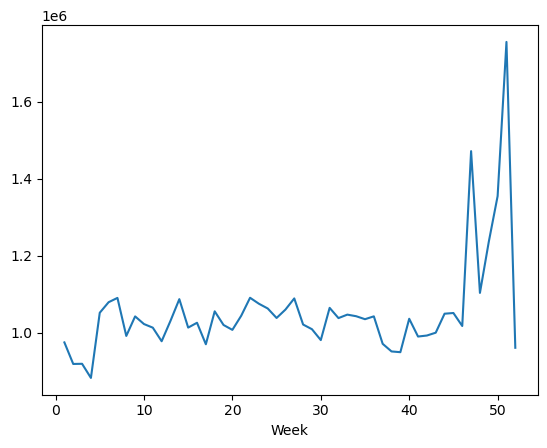

In [33]:
df.groupby('Week')['Weekly_Sales'].mean().plot()

In [34]:
#Observation:
#Sales remain fairly stable for most weeks, fluctuating around an average range.
#There are significant spikes in the later weeks (around week 47–52).
#After the peak, there is a sharp drop in sales.

In [35]:
#Interpretation:
#The spikes in the final weeks indicate high seasonal demand, likely due to major holidays and year-end shopping periods.
#The sharp decline after the peak suggests that this demand is short-lived and event-driven.
#The consistent pattern during earlier weeks shows steady baseline demand throughout the year.

In [36]:
#Business Insight:
#Weeks near the end of the year are critical for revenue generation.
#Businesses should:
#Increase stock availability before these peak weeks
#Plan marketing campaigns around these periods
#Post-peak drop indicates a need for:
#Retention strategies or promotions

### 4.Year-wise Trend

<Axes: xlabel='Year'>

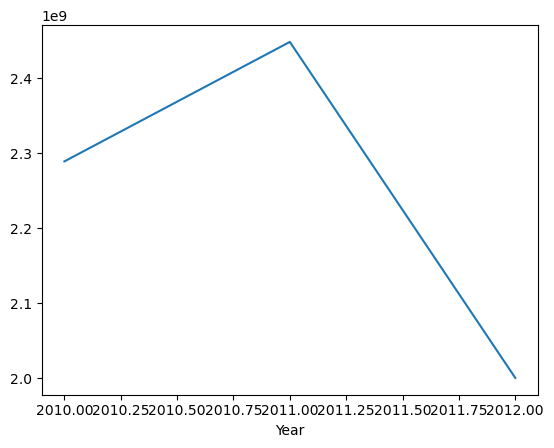

In [37]:
df.groupby('Year')['Weekly_Sales'].sum().plot()

In [38]:
#Observation:
#Sales increase from 2010 to 2011.
#There is a sharp decline in 2012 compared to 2011.

In [39]:
#Interpretation:
#The growth from 2010 to 2011 indicates improving business performance or higher demand during that period.
#The sudden drop in 2012 suggests a possible decline in sales performance, which could be due to:
#Reduced demand
#External economic factors
#Incomplete data for 2012 (very important possibility)

In [40]:
#Business Insight:
#2011 appears to be the peak performance year.
#The decline in 2012 needs further investigation before making decisions:
#If it’s real → indicates business slowdown
#If data is incomplete → not a reliable conclusion

In [41]:
#The drop in 2012 might be due to incomplete data, so conclusions should be made cautiously.

### 5: Store-wise Analysis

In [42]:
df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
19    2.066349e+08
31    1.996139e+08
23    1.987506e+08
24    1.940160e+08
11    1.939628e+08
28    1.892637e+08
41    1.813419e+08
32    1.668192e+08
18    1.551147e+08
22    1.470756e+08
12    1.442872e+08
26    1.434164e+08
34    1.382498e+08
40    1.378703e+08
35    1.315207e+08
8     1.299512e+08
17    1.277821e+08
45    1.123953e+08
21    1.081179e+08
25    1.010612e+08
43    9.056544e+07
15    8.913368e+07
7     8.159828e+07
42    7.956575e+07
9     7.778922e+07
29    7.714155e+07
16    7.425243e+07
37    7.420274e+07
30    6.271689e+07
3     5.758674e+07
38    5.515963e+07
36    5.341221e+07
5     4.547569e+07
44    4.329309e+07
33    3.716022e+07
Name: Weekly_Sales, dtype: float64

In [43]:
#Observation:
#There is a significant variation in sales across stores.
#A few stores such as Store 20, Store 4, and Store 14 generate the highest total sales.
#Some stores like Store 33, Store 44, and Store 5 show very low sales performance.
#The distribution indicates that sales are not evenly spread across all stores.

In [44]:
#Interpretation:
#The results show that a small number of stores contribute a large portion of total revenue.
#High-performing stores may be located in:
#High-demand regions
#Urban areas
#Locations with better customer traffic
#Low-performing stores may be affected by:
#Poor location
#Lower demand
#Operational inefficiencies

In [45]:
#Business Insight:
#Walmart should focus on:
#Maintaining and supporting top-performing stores to maximize revenue
#Investigating low-performing stores to identify issues
#Strategies such as:
#Promotions
#Store optimization
#Regional analysis can help improve underperforming stores

In [46]:
#Sales distribution across stores is highly skewed, with a few stores contributing significantly more revenue than others

### 6: Holiday Impact (Very Important)

In [47]:
df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64

In [48]:
#Observation:
#Average sales during non-holiday weeks (0) ≈ 1.04 million
#Average sales during holiday weeks (1) ≈ 1.12 million
#Sales are higher during holiday periods compared to normal weeks

In [49]:
#Interpretation:
#The data clearly shows that holiday weeks generate higher sales than non-holiday weeks.
#This indicates increased customer spending during holidays, likely due to:
#Festive shopping
#Promotions and discounts
#Increased consumer demand

In [50]:
#Business Insight:
#Holidays play a significant role in boosting revenue
#Walmart should:
#Increase inventory before holidays
#Run targeted marketing campaigns
#Optimize pricing and offers during these periods

In [51]:
#Holiday periods positively impact sales, showing higher average revenue compared to non-holiday weeks, indicating strong seasonal demand

In [52]:
#The difference is noticeable but not extremely large, suggesting that while holidays boost sales, baseline demand remains strong

### Correlation Analysis

In [53]:
#1. Select Numerical Columns Only

In [54]:
num_df = df.select_dtypes(include=['int64', 'float64'])

In [55]:
#2. Compute Correlation Matrix

In [56]:
corr = num_df.corr()
corr

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Week
Store,1.000000e+00,-0.335332,1.637929e-16,-0.022659,0.060023,-0.209492,0.223531,-1.418774e-16
Weekly_Sales,-3.353320e-01,1.000000,3.689097e-02,-0.063810,0.009464,-0.072634,-0.106176,7.421127e-02
Holiday_Flag,1.637929e-16,0.036891,1.000000e+00,-0.155091,-0.078347,-0.002162,0.010960,1.277427e-01
Temperature,-2.265908e-02,-0.063810,-1.550913e-01,1.000000,0.144982,0.176888,0.101158,2.361833e-01
Fuel_Price,6.002295e-02,0.009464,-7.834652e-02,0.144982,1.000000,-0.170642,-0.034684,-3.240300e-02
CPI,-2.094919e-01,-0.072634,-2.162091e-03,0.176888,-0.170642,1.000000,-0.302020,6.041530e-03
Unemployment,2.235313e-01,-0.106176,1.096028e-02,0.101158,-0.034684,-0.302020,1.000000,-1.589158e-02
Week,-1.418774e-16,0.074211,1.277427e-01,0.236183,-0.032403,0.006042,-0.015892,1.000000e+00


In [57]:
# 3. Visualize Using Heatmap 

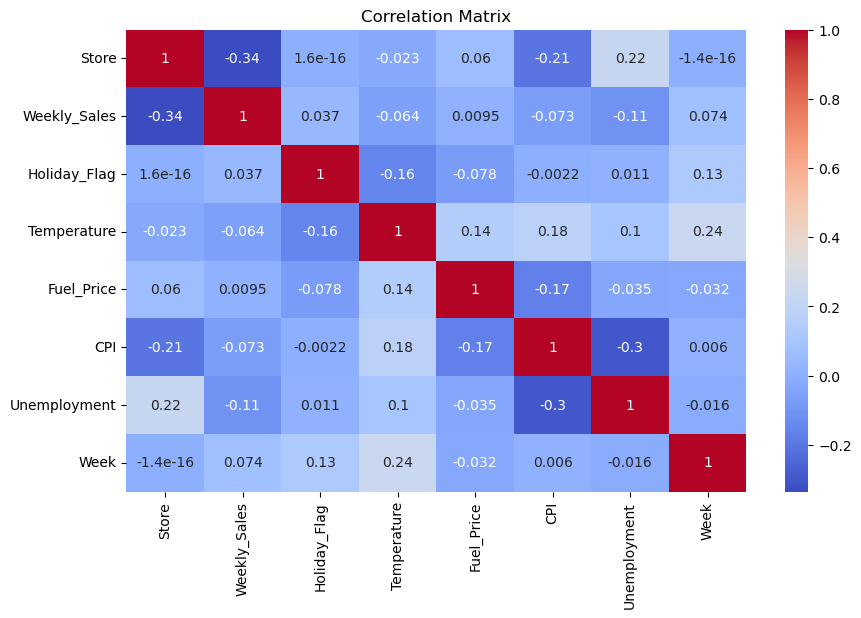

In [58]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [59]:
### Focus: Relationship with Weekly_Sales

In [60]:
#Observation:
#Store → -0.34 (moderate negative correlation)
#Unemployment → -0.11 (weak negative)
#CPI → -0.073 (very weak negative)
#Temperature → -0.064 (very weak negative)
#Holiday_Flag → 0.037 (very weak positive)
#Fuel_Price → 0.009 (almost no correlation)
#Week → 0.074 (very weak positive)

In [61]:
#Interpretation:
#Most features show very weak correlation with Weekly_Sales
#This means:
# Sales are not strongly dependent on individual variables alone
#Store (-0.34) has the highest impact:
#Different stores perform differently (you already saw this in store analysis)
#Economic factors like:
#CPI
#Unemployment
#Fuel Price
# Have minimal direct impact on sales

In [62]:
#Business Insight:
#Sales are likely influenced by:
# Combination of factors
# Seasonal patterns (you saw earlier)
# Store-specific behavior
#Not just single variables

In [63]:
#“Correlation analysis shows that no single feature strongly influences sales, indicating that sales prediction requires combining multiple features and possibly capturing time-based patterns.”

In [64]:
#“Low linear correlation suggests that non-linear models like Random Forest or XGBoost may perform better than simple linear regression.”

### Feature Selection (Train-test-split)

#### Step 1: Define Features & Target

In [65]:
X = df.drop(['Weekly_Sales', 'Date'], axis=1)
y = df['Weekly_Sales']

In [66]:
#We remove:
#Weekly_Sales (target)
#Date (not directly usable in ML)

#### Step 2: Train-Test Split

In [67]:
train = df[df['Date'] < '2012-01-01']
test = df[df['Date'] >= '2012-01-01']

X_train = train.drop(['Weekly_Sales', 'Date'], axis=1)
y_train = train['Weekly_Sales']

X_test = test.drop(['Weekly_Sales', 'Date'], axis=1)
y_test = test['Weekly_Sales']

####  Step 3: Train ML Models

### 1. Linear Regression

In [68]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### 2. Random Forest

In [69]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

### 3. XGBoost 

In [70]:
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

### Step 4: Evaluation 

In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_test, y_pred, name):
    print(f"{name} MAE:", mean_absolute_error(y_test, y_pred))
    print(f"{name} RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("------------")

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_xgb, "XGBoost")

Linear Regression MAE: 419122.31299968826
Linear Regression RMSE: 510406.03518913186
------------
Random Forest MAE: 157465.04263777775
Random Forest RMSE: 281994.20742119773
------------
XGBoost MAE: 120005.94442748708
XGBoost RMSE: 205109.0080227893
------------


In [72]:
#| Model             | MAE   | RMSE  |
#| ----------------- | ----- | ----- |
#| Linear Regression | ~419K | ~510K |
#| Random Forest     | ~157K | ~282K |
#| XGBoost           | ~120K | ~205K |


In [73]:
#Observation
#XGBoost performs best (lowest MAE & RMSE)
#Random Forest is second best
#Linear Regression performs worst

In [74]:
#“XGBoost achieved the best performance with the lowest RMSE,
#indicating that sales data has non-linear patterns that are better
#captured by boosting models compared to linear regression.”

In [75]:
#“The significant improvement from Linear Regression to tree-based models 
#confirms the earlier correlation analysis, which showed weak linear relationships.”

In [76]:
#How Good Are  Numbers?
#RMSE ≈ 205K
#Reasonable
# Not overfitting

### 1.Actual vs Predicted Plot

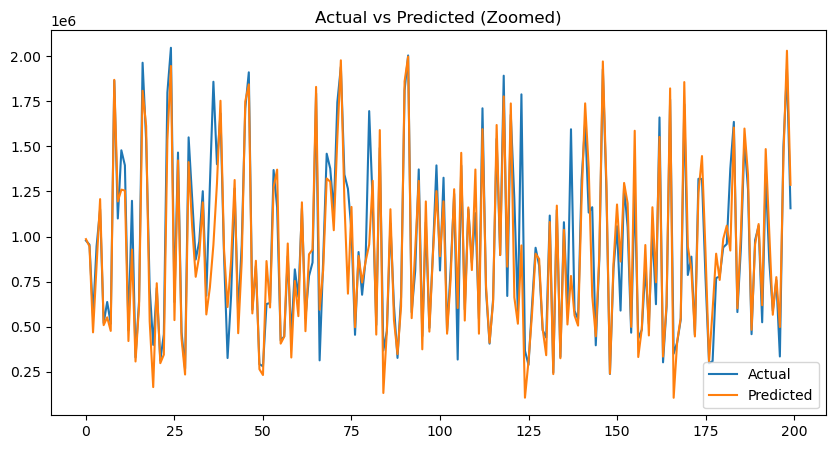

In [77]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred_xgb[:200], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted (Zoomed)")
plt.show()

In [78]:
#"The predicted values closely follow the actual trend, indicating good model performance, 
#although slight deviations at peak values suggest room for improvement in capturing extreme events.”

### 2. Feature Importance 

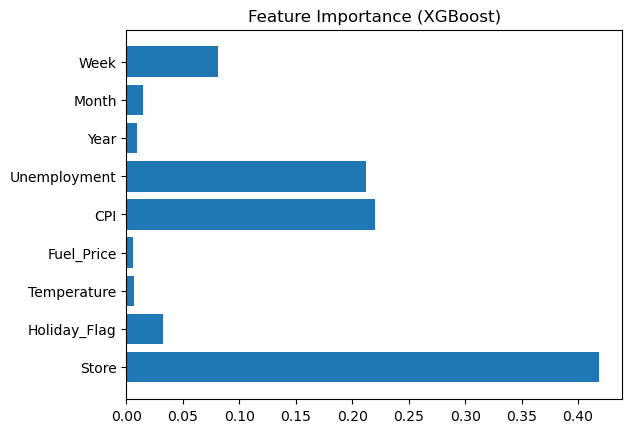

In [79]:
importances = xgb.feature_importances_
features = X_train.columns

plt.barh(features, importances)
plt.title("Feature Importance (XGBoost)")
plt.show()

### LSTM (Deep Learning)
#### Capture time dependencies better
#### Improve sequential prediction

#### Goal of LSTM
#### Unlike ML models, LSTM learns:
#### “Past sales → predict next sales”

Epoch 1/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0271 - val_loss: 0.0229
Epoch 2/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0256 - val_loss: 0.0220
Epoch 3/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0256 - val_loss: 0.0221
Epoch 4/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0255 - val_loss: 0.0223
Epoch 5/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0252 - val_loss: 0.0221
Epoch 6/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0253 - val_loss: 0.0223
Epoch 7/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0251 - val_loss: 0.0218
Epoch 8/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0251 - val_loss: 0.0219
Epoch 9/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0251 - val_loss: 0.0225
Epoch 10/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0251 - val_loss: 0.0219
Epoch 11/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0250 - val_loss: 0.0218
Epoch 12/30
161/161 ━━━━━━━━━━━━━━━━━━━━

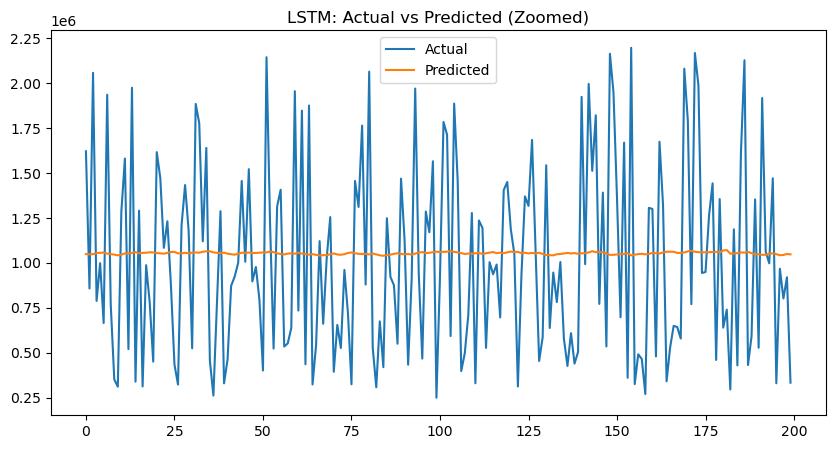

In [80]:
# =========================
# 🔥 Improved Multivariate LSTM (Single Cell)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# 🔹 1. Select Features
features = ['Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
data = df[features].values

# 🔹 2. Scale Data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# 🔹 3. Create Sequences
X, y = [], []
time_step = 12

for i in range(time_step, len(data_scaled)):
    X.append(data_scaled[i-time_step:i])
    y.append(data_scaled[i, 0])  # Weekly_Sales

X, y = np.array(X), np.array(y)

# 🔹 4. Train-Test Split (Time-based)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 🔹 5. Build Model
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    LSTM(64, return_sequences=True),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# 🔹 6. Train Model
model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# 🔹 7. Predictions
y_pred = model.predict(X_test)

# 🔹 8. Inverse Scaling
dummy_pred = np.zeros((len(y_pred), data.shape[1]))
dummy_pred[:, 0] = y_pred[:, 0]
y_pred = scaler.inverse_transform(dummy_pred)[:, 0]

dummy_test = np.zeros((len(y_test), data.shape[1]))
dummy_test[:, 0] = y_test
y_test = scaler.inverse_transform(dummy_test)[:, 0]

# 🔹 9. Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("✅ Improved LSTM RMSE:", rmse)

# 🔹 10. Plot (Zoomed)
plt.figure(figsize=(10,5))
plt.plot(y_test[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')
plt.legend()
plt.title("LSTM: Actual vs Predicted (Zoomed)")
plt.show()

### Final Conclusion Section

In [81]:
#“I experimented with both machine learning and deep learning approaches
#and selected XGBoost as the final model based on empirical performance.”

In [82]:
# because,“Among all models, XGBoost achieved the best performance.
#Although LSTM was implemented to capture temporal dependencies, 
#it did not outperform tree-based models, indicating that 
#the dataset is better suited for traditional machine learning techniques.”

In [92]:
import joblib

joblib.dump(xgb, "model.pkl")

['model.pkl']

In [93]:
model = joblib.load(r"C:\Users\kusuma\model.pkl")

In [94]:
import joblib

model = joblib.load(r"C:\Users\kusuma\model.pkl")
print("Model loaded successfully")

Model loaded successfully
